# 🧠 AI Focus & Productivity Predictor

This project simulates how environmental and lifestyle factors 
affect human focus and productivity using machine learning.

## Objective
To estimate performance impact (%) based on:
- Weather conditions
- Air quality
- Sleep & lifestyle habits

## Models Used
- Ridge Regression (Baseline)
- Random Forest Regressor (Primary Model)

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Generate Synthetic Dataset

In [2]:
np.random.seed(42)
n = 8000

# Environmental Factors
temperature = np.random.uniform(5, 45, n)
humidity = np.random.uniform(20, 95, n)
aqi = np.random.uniform(20, 400, n)
pressure = np.random.uniform(980, 1035, n)
wind_speed = np.random.uniform(0, 15, n)

# Lifestyle Factors
sleep_hours = np.random.uniform(3, 9, n)
hydration_level = np.random.randint(1, 6, n)
caffeine_intake = np.random.randint(0, 6, n)
noise_level = np.random.uniform(30, 90, n)
screen_time = np.random.uniform(0, 8, n)
environment = np.random.randint(0, 2, n)

# Target Engineering (Core Logic)

In [3]:
degradation = (
    0.3 * temperature +
    0.25 * humidity +
    0.6 * (aqi / 10) +
    0.35 * noise_level +
    1.2 * (8 - sleep_hours) ** 2 +
    0.8 * (5 - hydration_level) ** 2 +
    0.5 * screen_time +
    3 * environment
)

# Extreme penalties
degradation += np.where(aqi > 300, 15, 0)
degradation += np.where(sleep_hours < 4, 10, 0)
degradation += np.where(temperature > 40, 8, 0)

degradation = np.clip(degradation / 4.5, 0, 45)

# Create DataFrame

In [4]:
df = pd.DataFrame({
    "temperature": temperature,
    "humidity": humidity,
    "aqi": aqi,
    "pressure": pressure,
    "wind_speed": wind_speed,
    "sleep_hours": sleep_hours,
    "hydration_level": hydration_level,
    "caffeine_intake": caffeine_intake,
    "noise_level": noise_level,
    "screen_time": screen_time,
    "environment": environment,
    "degradation": degradation
})

df.head()

,temperature,humidity,aqi,pressure,wind_speed,sleep_hours,hydration_level,caffeine_intake,noise_level,screen_time,environment,degradation
0,19.981605,74.020094,21.672611,1017.704041,0.399866,4.793472,5,2,61.748494,0.072891,1,13.952548
1,43.028572,71.546225,20.125461,1005.716403,0.119409,3.568907,5,0,37.327182,4.388442,0,19.738421
2,34.279758,27.181565,199.460115,983.063879,3.365632,3.758155,3,5,61.826051,2.335540,1,19.921268
3,28.946339,89.192930,31.131608,1030.518058,11.989814,4.084027,3,4,64.646362,1.701514,1,17.984184
4,11.240746,62.635415,390.322370,1033.918102,13.571215,4.221920,4,5,87.217796,6.936078,1,24.971856


# Data Overview

In [5]:
df.describe()

,temperature,humidity,aqi,pressure,wind_speed,sleep_hours,hydration_level,caffeine_intake,noise_level,screen_time,environment,degradation
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,24.791520,57.323358,214.460927,1007.247400,7.458558,5.994154,2.995000,2.494625,60.237664,3.985193,0.498000,17.614172
std,11.559718,21.649117,109.411111,15.787411,4.320752,1.743415,1.408979,1.710654,17.406810,2.327545,0.500027,4.595361
min,5.000465,20.003962,20.018287,980.003712,0.000083,3.000100,1.000000,0.000000,30.002852,0.000921,0.000000,5.814005
25%,14.733700,38.640195,122.217672,993.569384,3.705526,4.465000,2.000000,1.000000,45.325426,1.964171,0.000000,14.168295
50%,24.720257,57.024053,216.092752,1007.261751,7.497814,5.975236,3.000000,2.500000,59.921824,3.958687,0.000000,17.240614
75%,34.729325,76.414543,307.865173,1020.720656,11.157927,7.540170,4.000000,4.000000,75.631722,6.033161,1.000000,20.630158
max,44.988707,94.994362,399.962371,1034.985265,14.996841,8.999833,5.000000,5.000000,89.993702,7.999143,1.000000,33.848193


# Correlation Heatmap

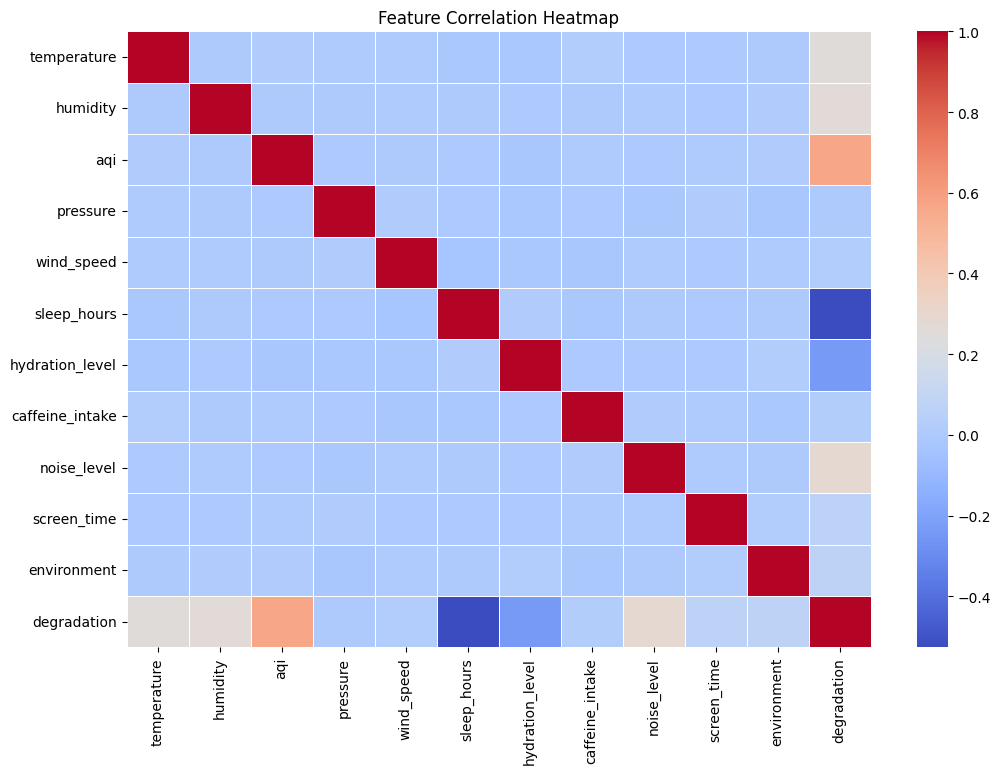

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Train-Test Split

In [7]:
X = df.drop("degradation", axis=1)
y = df["degradation"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Models

In [9]:
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)

rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=12, n_estimators=400, random_state=42)

# Feature Importance

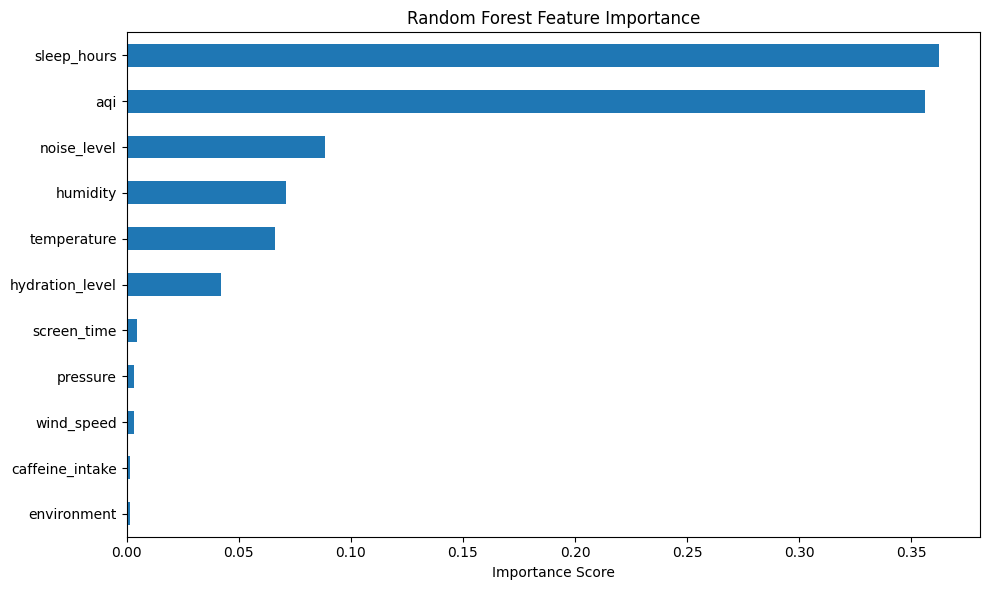

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Model Evaluation

In [10]:
ridge_pred = ridge_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)

print("Ridge R2 Score:", r2_score(y_test, ridge_pred))
print("Random Forest R2 Score:", r2_score(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Ridge R2 Score: 0.8632728520896273
Random Forest R2 Score: 0.9632331733663088
Random Forest RMSE: 0.8781802785265673


# Save Models for Deployment

In [11]:
joblib.dump(ridge_model, "model/best_ridge_model.pkl")
joblib.dump(rf_model, "model/random_forest_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']